# UTS Praktikum Machine Learning



Notebook ini berisi alur lengkap untuk dataset agro-environmental:
1. Memuat dataset dan inspeksi awal
2. EDA: missing values, duplikasi, distribusi target, dan korelasi
3. Preprocessing: imputasi, encoding, scaling
4. Baseline model, hyperparameter tuning, dan cross-validation
5. Ensemble learning
6. Evaluasi model
7. Menyimpan model final untuk integrasi FastAPI + Streamlit

### **Kelompok 8**

1. Maulizar (2308107010007)
2. Nadia Maghdalena (2308107010045)
3. Khairun Nisa (2308107010074)

In [51]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1) Load Data dan Cek Awal

Dataset utama: `dataset/agro_environmental_dataset.csv`

In [52]:
data_path = "dataset/agro_environmental_dataset.csv"
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (543210, 25)
Columns: ['location_id', 'soil_type', 'bulk_density', 'organic_matter_pct', 'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity', 'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet', 'moisture_regime', 'soil_temp_c', 'air_temp_c', 'thermal_regime', 'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm', 'nutrient_balance', 'plant_category', 'suitability_score', 'stress_level', 'failure_flag']


,location_id,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,L00000,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,L00001,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,L00002,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,L00003,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,L00004,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


## 2) EDA: Missing Values, Duplikasi, Distribusi Target, dan Imbalance

<class 'pandas.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  str    
 1   soil_type                 543210 non-null  str    
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  str    
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime            543210 non-null  str    
 14 

,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,soil_temp_c,air_temp_c,light_intensity_par,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,suitability_score,stress_level,failure_flag
count,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000
mean,1.319365,4.000303,17.212248,0.673847,0.610260,34.977238,16.945798,42.566326,25.003662,28.007091,699.682397,6.499156,0.206417,100.369819,50.593494,110.290247,0.613343,0.914698,0.162147
std,0.243070,4.278072,10.367455,0.986025,0.198579,11.927853,6.615230,9.681918,4.991071,5.379043,288.943448,0.892323,0.404734,39.138892,23.827609,43.769883,0.246283,0.743454,0.368586
min,0.700000,1.200000,5.000000,0.200000,0.300000,5.000000,8.000000,28.000000,10.000000,7.000000,200.000000,4.000000,0.000000,20.000000,10.000000,20.000000,0.000000,0.000000,0.000000
25%,1.300000,1.800000,8.000000,0.300000,0.400000,26.870000,12.000000,38.000000,21.600000,24.400000,450.000000,5.890000,0.000000,73.000000,33.100000,79.700000,0.457000,0.000000,0.000000
50%,1.300000,3.500000,15.000000,0.400000,0.700000,34.970000,16.000000,42.000000,25.000000,28.000000,699.000000,6.500000,0.000000,100.000000,50.100000,110.000000,0.628000,1.000000,0.000000
75%,1.500000,3.800000,20.000000,0.500000,0.700000,43.070000,22.000000,45.000000,28.400000,31.600000,949.000000,7.110000,0.000000,127.000000,66.900000,140.300000,0.784000,1.000000,0.000000
max,1.600000,18.000000,40.000000,4.000000,0.900000,70.000000,30.000000,65.000000,40.000000,49.600000,1200.000000,8.800000,1.000000,220.000000,159.000000,220.000000,1.000000,2.000000,1.000000



Jumlah baris duplikat: 0

Distribusi target awal (termasuk missing):
failure_flag
0    455130
1     88080
Name: count, dtype: int64


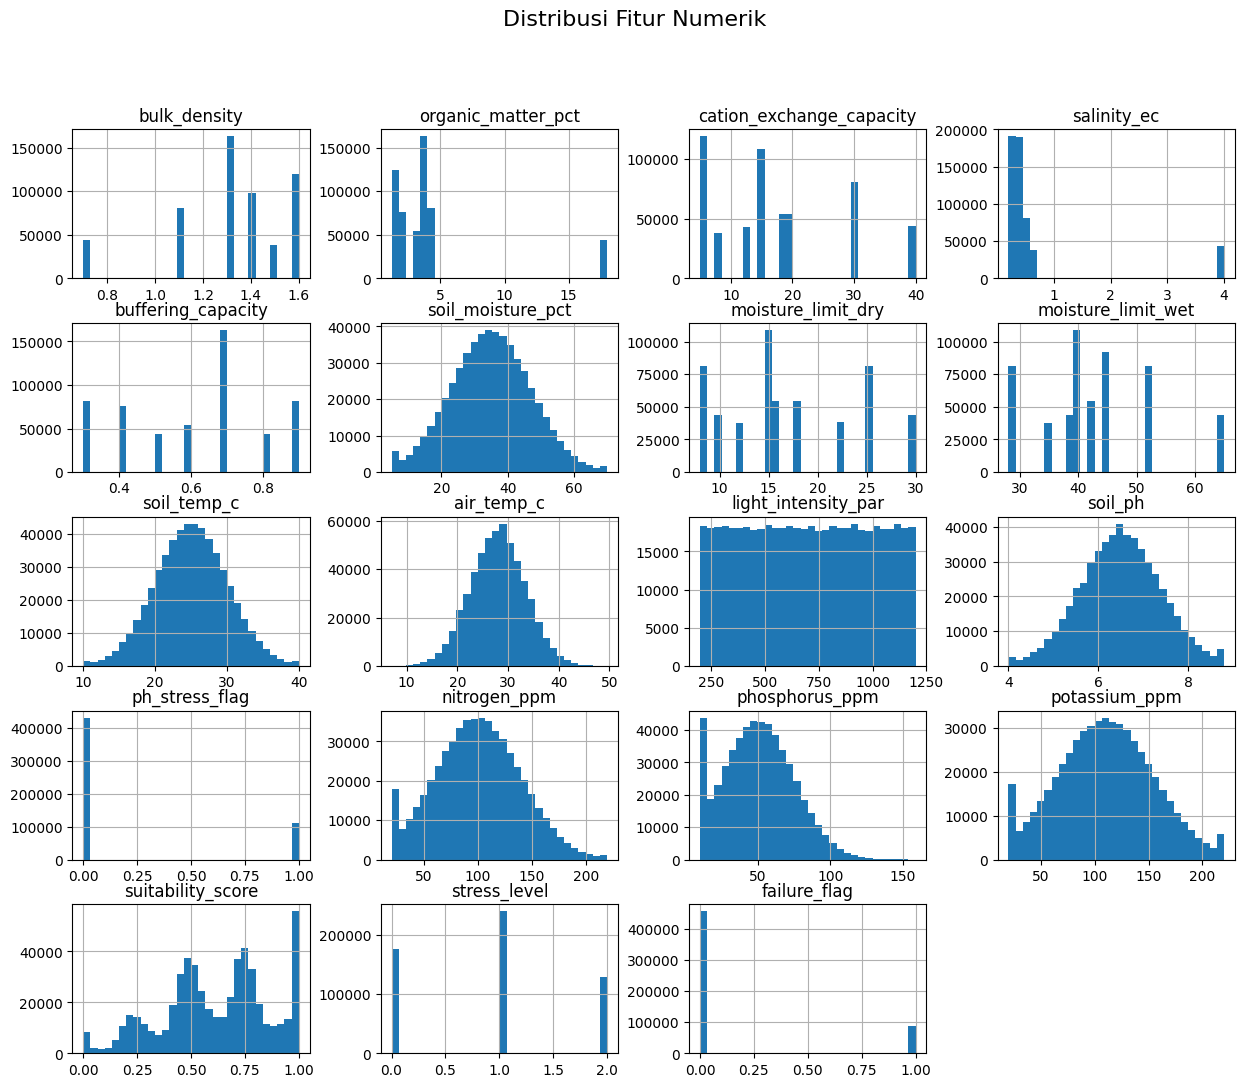

In [53]:
# Cek tipe data dan ringkasan
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

# Statistik deskriptif
print("\nStatistik deskriptif:")
display(df.describe())

# Cek duplikasi
dup_count = df.duplicated().sum()
print(f"\nJumlah baris duplikat: {dup_count}")

# Distribusi target awal
print("\nDistribusi target awal (termasuk missing):")
print(df["failure_flag"].value_counts(dropna=False))

# Distribusi fitur numerik
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribusi Fitur Numerik", fontsize=16)
plt.show()

### Insight Data Awal

- Dataset memiliki 543.210 baris dan 25 fitur.
- Tidak ditemukan missing values pada seluruh kolom, sehingga tidak diperlukan imputasi data.
- Dataset terdiri dari kombinasi fitur numerik dan kategorikal.
- Hal ini memungkinkan penggunaan pipeline preprocessing yang menggabungkan scaling dan encoding.

In [54]:
# Data cleaning: hapus duplikat dan baris dengan target kosong
clean_df = df.drop_duplicates().copy()
clean_df = clean_df[clean_df["failure_flag"].notna()].copy()
clean_df["failure_flag"] = clean_df["failure_flag"].astype(int)

print("Shape setelah cleaning:", clean_df.shape)

print("Distribusi target setelah cleaning:")
print(clean_df["failure_flag"].value_counts(normalize=True).rename("proporsi"))

print("\nMissing values setelah cleaning:")
print(clean_df.isna().sum().sort_values(ascending=False))

Shape setelah cleaning: (543210, 25)
Distribusi target setelah cleaning:
failure_flag
0    0.837853
1    0.162147
Name: proporsi, dtype: float64

Missing values setelah cleaning:
location_id                 0
soil_type                   0
bulk_density                0
organic_matter_pct          0
cation_exchange_capacity    0
salinity_ec                 0
buffering_capacity          0
soil_moisture_pct           0
moisture_limit_dry          0
moisture_limit_wet          0
moisture_regime             0
soil_temp_c                 0
air_temp_c                  0
thermal_regime              0
light_intensity_par         0
soil_ph                     0
ph_stress_flag              0
nitrogen_ppm                0
phosphorus_ppm              0
potassium_ppm               0
nutrient_balance            0
plant_category              0
suitability_score           0
stress_level                0
failure_flag                0
dtype: int64


### Data Cleaning

- Baris duplikat dihapus untuk menghindari bias dalam model.
- Baris dengan target kosong dihapus karena tidak dapat digunakan dalam supervised learning.
- Tidak ditemukan missing values pada fitur lain, sehingga tidak diperlukan imputasi tambahan.

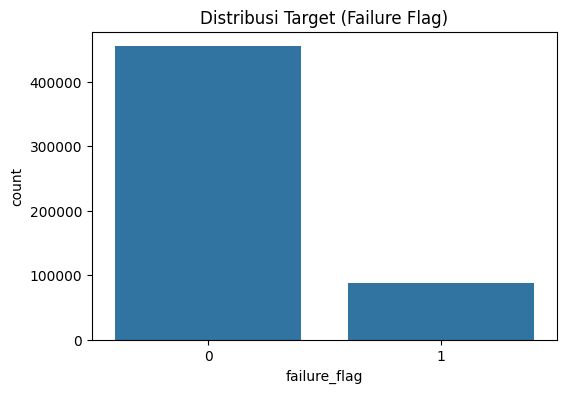

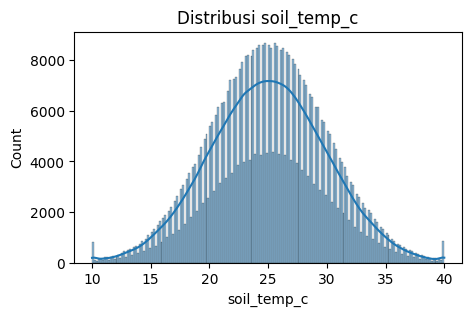

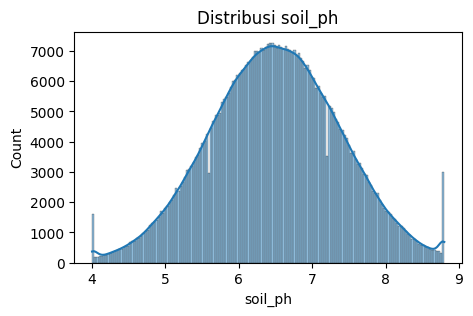

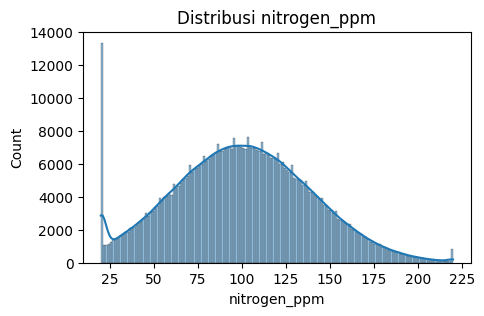

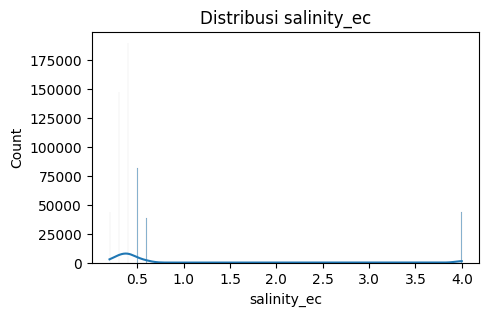

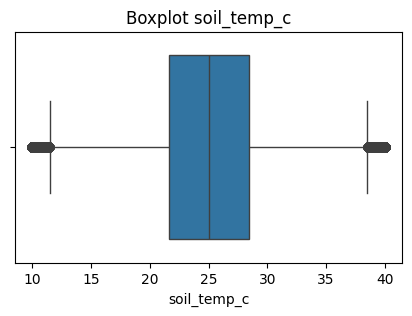

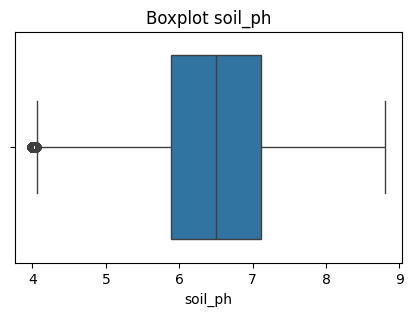

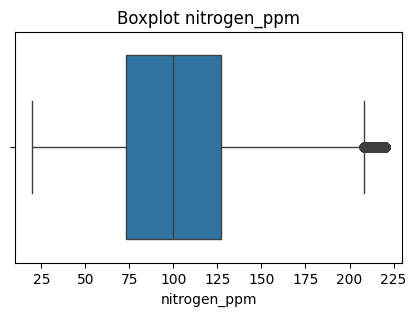

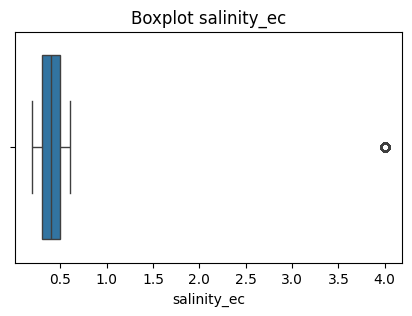

In [55]:
# DISTRIBUSI TARGET (VISUAL)
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x=clean_df["failure_flag"])
plt.title("Distribusi Target (Failure Flag)")
plt.show()


# DISTRIBUSI FITUR PENTING
selected_plot_cols = [
    "soil_temp_c",
    "soil_ph",
    "nitrogen_ppm",
    "salinity_ec"
]

for col in selected_plot_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(clean_df[col], kde=True)
    plt.title(f"Distribusi {col}")
    plt.show()


# BOXPLOT (OUTLIER DETECTION)
for col in selected_plot_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=clean_df[col])
    plt.title(f"Boxplot {col}")
    plt.show()

### Visualisasi Distribusi Data dan Deteksi Outlier

Visualisasi dilakukan untuk memahami karakteristik data secara lebih mendalam, khususnya distribusi target dan fitur-fitur penting.

#### Distribusi Target
Plot distribusi target (`failure_flag`) digunakan untuk melihat proporsi masing-masing kelas. Dari visualisasi ini dapat diamati bahwa dataset bersifat tidak seimbang (*imbalanced*), dimana salah satu kelas mendominasi.

#### Distribusi Fitur Numerik
Beberapa fitur penting seperti `soil_temp_c`, `soil_ph`, `nitrogen_ppm`, dan `salinity_ec` divisualisasikan menggunakan histogram dan kurva densitas (*kernel density estimation*). Visualisasi ini membantu dalam memahami:
- Pola distribusi data (normal, skewed, dll)
- Rentang nilai fitur
- Potensi adanya anomali atau distribusi yang tidak merata

#### Deteksi Outlier
Boxplot digunakan untuk mengidentifikasi adanya outlier pada fitur numerik. Outlier merupakan nilai ekstrem yang berada jauh dari distribusi utama data dan berpotensi mempengaruhi performa model.

Berdasarkan visualisasi, beberapa fitur menunjukkan adanya nilai ekstrem, namun tidak dilakukan penghapusan secara langsung karena model yang digunakan (misalnya Random Forest) relatif robust terhadap outlier.

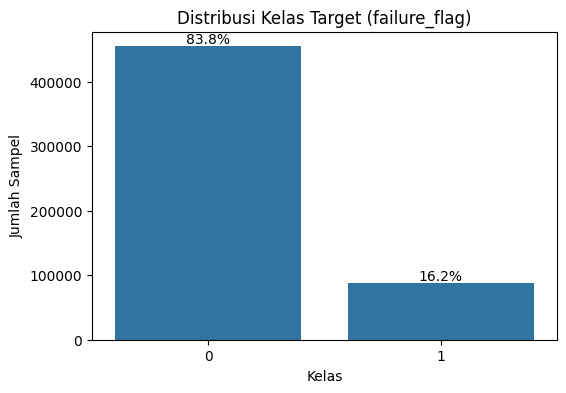

Proporsi kelas:
failure_flag
0    0.837853
1    0.162147
Name: proportion, dtype: float64


In [56]:
# Visualisasi imbalance target
plt.figure(figsize=(6, 4))
sns.countplot(x=clean_df["failure_flag"])

plt.title("Distribusi Kelas Target (failure_flag)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Sampel")

total = len(clean_df)
for p in plt.gca().patches:
    height = p.get_height()
    plt.text(p.get_x() + p.get_width() / 2, height,
             f'{(height/total)*100:.1f}%',
             ha='center', va='bottom')

plt.show()

# Tampilkan proporsi numerik juga
print("Proporsi kelas:")
print(clean_df["failure_flag"].value_counts(normalize=True))

### Analisis Imbalanced Dataset

Distribusi kelas target menunjukkan adanya ketidakseimbangan antara kelas "Failure" dan "No Failure".

Untuk mengatasi hal ini, digunakan teknik `class_weight` pada model yang secara otomatis menyesuaikan bobot masing-masing kelas berdasarkan proporsinya.

Pendekatan ini membantu model agar tidak bias terhadap kelas mayoritas.

## 3) Seleksi Fitur dan Analisis Korelasi

Kolom identitas dan kolom turunan yang berpotensi leakage tidak dipakai untuk training model final.

In [57]:
# FEATURE SELECTION & DATA LEAKAGE HANDLING

target_col = "failure_flag"

# Kolom yang berpotensi menyebabkan data leakage / terlalu kuat
leakage_features = [
    "location_id",
    "suitability_score",
    "stress_level",
    "ph_stress_flag",
    "nutrient_balance"
]

# Drop leakage features
clean_df = clean_df.drop(columns=leakage_features, errors="ignore").copy()

# Pilih fitur yang digunakan
selected_features = [
    "soil_type",
    "bulk_density",
    "organic_matter_pct",
    "cation_exchange_capacity",
    "salinity_ec",
    "buffering_capacity",
    "soil_moisture_pct",
    "moisture_limit_dry",
    "moisture_limit_wet",
    "moisture_regime",
    "soil_temp_c",
    "air_temp_c",
    "thermal_regime",
    "light_intensity_par",
    "soil_ph",
    "nitrogen_ppm",
    "phosphorus_ppm",
    "potassium_ppm",
    "plant_category",
]

# Validasi kolom
missing_cols = [col for col in selected_features if col not in clean_df.columns]
if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan di dataset: {missing_cols}")

# Dataset final untuk modeling
model_df = clean_df[selected_features + [target_col]].copy()

# Pisahkan fitur numerik & kategorikal
numeric_features = [
    "bulk_density",
    "organic_matter_pct",
    "cation_exchange_capacity",
    "salinity_ec",
    "buffering_capacity",
    "soil_moisture_pct",
    "moisture_limit_dry",
    "moisture_limit_wet",
    "soil_temp_c",
    "air_temp_c",
    "light_intensity_par",
    "soil_ph",
    "nitrogen_ppm",
    "phosphorus_ppm",
    "potassium_ppm",
]

categorical_features = [
    "soil_type",
    "moisture_regime",
    "thermal_regime",
    "plant_category",
]

# Info
print("Kolom yang dihapus (leakage / high-risk):", leakage_features)
print("Shape dataset setelah feature selection:", model_df.shape)

print("\nUnique values pada fitur kategorikal:")
for col in categorical_features:
    print(f"- {col}: {model_df[col].nunique(dropna=False)}")

Kolom yang dihapus (leakage / high-risk): ['location_id', 'suitability_score', 'stress_level', 'ph_stress_flag', 'nutrient_balance']
Shape dataset setelah feature selection: (543210, 20)

Unique values pada fitur kategorikal:
- soil_type: 9
- moisture_regime: 3
- thermal_regime: 3
- plant_category: 3


### Feature Selection

Fitur yang digunakan dalam model dipilih berdasarkan relevansinya terhadap kondisi tanah dan faktor lingkungan yang mempengaruhi pertumbuhan tanaman.

Beberapa kolom seperti `location_id`, `suitability_score`, dan `stress_level` tidak digunakan dalam proses training karena berpotensi menyebabkan data leakage, yaitu kondisi di mana model memperoleh informasi yang tidak seharusnya tersedia saat proses prediksi sehingga dapat menghasilkan performa yang tidak realistis.

Selain itu, fitur turunan seperti `ph_stress_flag` dan `nutrient_balance` juga dihapus karena merupakan hasil transformasi dari fitur utama dan berpotensi menjadi shortcut dalam prediksi.

Fitur yang digunakan dalam model terdiri dari kombinasi variabel numerik dan kategorikal yang merepresentasikan kondisi fisik, kimia, serta lingkungan tanah, sehingga model dapat belajar pola secara lebih representatif dan general.

In [58]:
# # FEATURE SELECTION & DATA LEAKAGE HANDLING

# target_col = "failure_flag"

# # Kolom yang berpotensi menyebabkan data leakage
# leakage_features = ["location_id", "suitability_score", "stress_level"]

# # Drop leakage features
# clean_df = clean_df.drop(columns=leakage_features, errors="ignore")

# selected_features = [
#     "soil_type",
#     "bulk_density",
#     "organic_matter_pct",
#     "cation_exchange_capacity",
#     "salinity_ec",
#     "buffering_capacity",
#     "soil_moisture_pct",
#     "moisture_limit_dry",
#     "moisture_limit_wet",
#     "moisture_regime",
#     "soil_temp_c",
#     "air_temp_c",
#     "thermal_regime",
#     "light_intensity_par",
#     "soil_ph",
#     "ph_stress_flag",
#     "nitrogen_ppm",
#     "phosphorus_ppm",
#     "potassium_ppm",
#     "nutrient_balance",
#     "plant_category",
# ]

# # Dataset untuk modeling
# model_df = clean_df[selected_features + [target_col]].copy()

# # Pisahkan fitur
# numeric_features = [
#     "bulk_density",
#     "organic_matter_pct",
#     "cation_exchange_capacity",
#     "salinity_ec",
#     "buffering_capacity",
#     "soil_moisture_pct",
#     "moisture_limit_dry",
#     "moisture_limit_wet",
#     "soil_temp_c",
#     "air_temp_c",
#     "light_intensity_par",
#     "soil_ph",
#     "ph_stress_flag",
#     "nitrogen_ppm",
#     "phosphorus_ppm",
#     "potassium_ppm",
# ]

# categorical_features = [
#     "soil_type",
#     "moisture_regime",
#     "thermal_regime",
#     "nutrient_balance",
#     "plant_category",
# ]

# print("Kolom leakage yang dihapus:", leakage_features)

# print("\nUnique values pada fitur kategorikal:")
# for col in categorical_features:
#     print(f"- {col}: {model_df[col].nunique(dropna=False)}")

### Feature Selection

Fitur dipilih berdasarkan relevansi terhadap kondisi tanah dan lingkungan yang mempengaruhi pertumbuhan tanaman.

Kolom seperti `location_id`, `suitability_score`, dan `stress_level` tidak digunakan dalam proses training karena berpotensi menyebabkan data leakage, yaitu informasi yang tidak tersedia saat prediksi namun mempengaruhi target.

Fitur yang digunakan terdiri dari kombinasi variabel numerik dan kategorikal yang merepresentasikan kondisi fisik, kimia, dan lingkungan tanah.

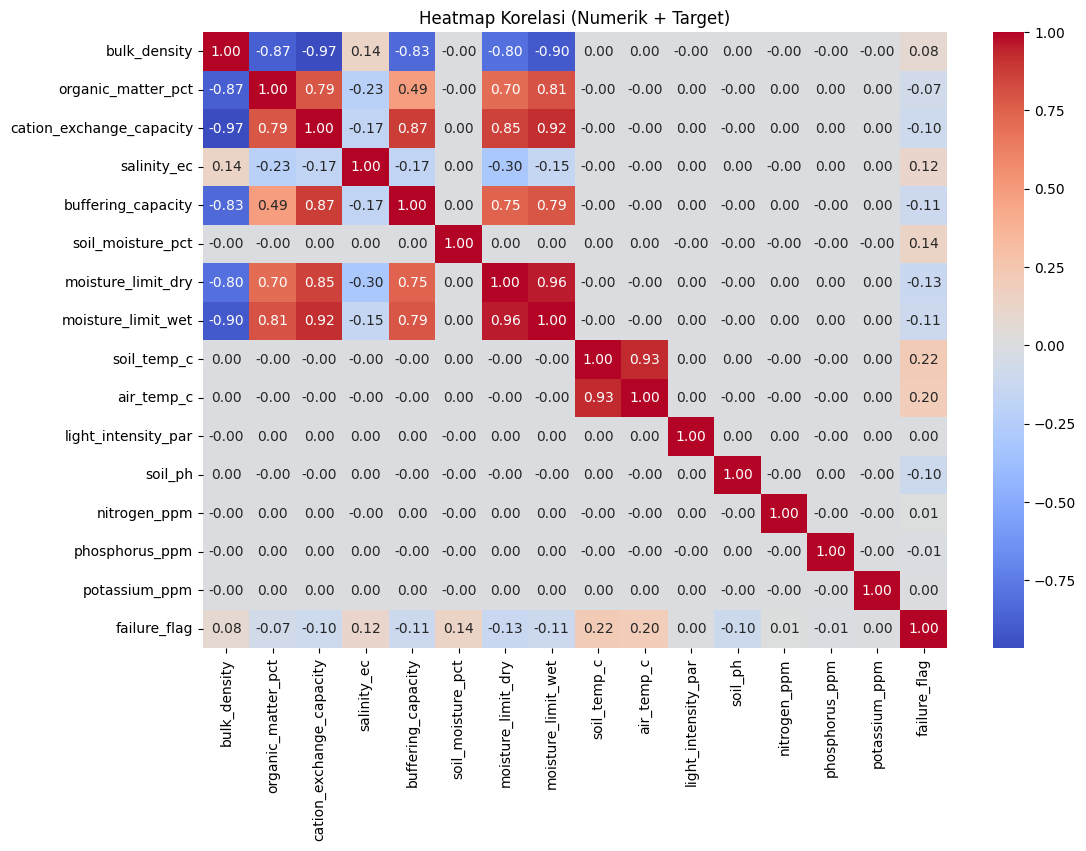


Fitur dengan korelasi tertinggi terhadap target:
failure_flag                1.000000
soil_temp_c                 0.216402
air_temp_c                  0.201002
soil_moisture_pct           0.137044
salinity_ec                 0.116752
bulk_density                0.084758
nitrogen_ppm                0.009500
potassium_ppm               0.001123
light_intensity_par         0.000776
phosphorus_ppm             -0.009802
organic_matter_pct         -0.069632
cation_exchange_capacity   -0.097666
soil_ph                    -0.099133
buffering_capacity         -0.108961
moisture_limit_wet         -0.111998
moisture_limit_dry         -0.127956
Name: failure_flag, dtype: float64

Pasangan fitur dengan korelasi tinggi (>0.9):
bulk_density  bulk_density                     NaN
              organic_matter_pct               NaN
              cation_exchange_capacity    0.966002
              salinity_ec                      NaN
              buffering_capacity               NaN
                     

In [59]:
# ANALISIS KORELASI

import seaborn as sns

corr_df = model_df[numeric_features + [target_col]].copy()
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi (Numerik + Target)")
plt.show()

# Ranking korelasi ke target
print("\nFitur dengan korelasi tertinggi terhadap target:")
print(corr[target_col].sort_values(ascending=False))

# CEK MULTICOLLINEARITY
high_corr = corr.abs()
high_corr_pairs = high_corr[(high_corr > 0.9) & (high_corr < 1.0)]

print("\nPasangan fitur dengan korelasi tinggi (>0.9):")
print(high_corr_pairs.stack())

### Analisis Korelasi

Heatmap korelasi digunakan untuk memahami hubungan antar fitur numerik serta hubungan antara fitur dengan target.

Beberapa fitur menunjukkan korelasi yang lebih tinggi terhadap target, yang mengindikasikan bahwa fitur tersebut memiliki kontribusi lebih besar dalam proses prediksi.

Selain itu, tidak ditemukan multicollinearity yang signifikan antar fitur (tidak ada korelasi yang sangat tinggi > 0.9), sehingga seluruh fitur masih layak digunakan dalam model.

Sebagai contoh, fitur seperti `soil_ph` dan `nitrogen_ppm` menunjukkan hubungan yang cukup kuat terhadap target.

## 4) Split Data dan Pipeline Preprocessing

In [60]:
# SPLIT DATA

X = model_df[selected_features].copy()
y = model_df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Sampling dipakai supaya baseline CV dan tuning tetap cepat di dataset yang besar
train_size = min(120000, len(X_train))
X_train_model, _, y_train_model, _ = train_test_split(
    X_train,
    y_train,
    train_size=train_size,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

# Sampling untuk hyperparameter tuning
search_size = min(40000, len(X_train_model))
X_search, _, y_search, _ = train_test_split(
    X_train_model,
    y_train_model,
    train_size=search_size,
    random_state=RANDOM_STATE,
    stratify=y_train_model,
)

# CROSS VALIDATION
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# HANDLE IMBALANCE

classes = np.unique(y_train_model)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_model
)

class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}

print("Class distribution (train_model):")
print(y_train_model.value_counts(normalize=True))

print("\nClass weights:", class_weight_dict)

Class distribution (train_model):
failure_flag
0    0.83785
1    0.16215
Name: proportion, dtype: float64

Class weights: {0: 0.5967655308229397, 1: 3.0835646006783843}


### Data Splitting

Dataset dibagi menjadi data training dan data testing dengan rasio 80:20 menggunakan teknik *stratified sampling* untuk menjaga proporsi distribusi kelas.

Berdasarkan data training, distribusi kelas menunjukkan kondisi *imbalanced*, dimana kelas mayoritas (No Failure) sebesar ±83.78% dan kelas minoritas (Failure) sebesar ±16.21%.

Untuk efisiensi komputasi pada dataset yang besar, dilakukan sampling pada data training:
- Sebanyak 120.000 data digunakan untuk pelatihan model
- Sebanyak 40.000 data digunakan untuk proses *hyperparameter tuning*

Pendekatan ini memungkinkan proses pelatihan dan tuning berjalan lebih cepat tanpa mengorbankan representasi distribusi data. Selain itu, untuk mengatasi ketidakseimbangan data, digunakan metode *class_weight* yang memberikan bobot lebih besar pada kelas minoritas.

In [61]:
# PREPROCESSING PIPELINE

# Numerical features: imputasi + scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical features: imputasi + encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Gabungkan preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# INFO DATA

print("\nTrain full shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train model shape:", X_train_model.shape)
print("Search shape:", X_search.shape)


Train full shape: (434568, 19)
Test shape: (108642, 19)
Train model shape: (120000, 19)
Search shape: (40000, 19)


### Preprocessing dan Penanganan Imbalanced Dataset

Berdasarkan distribusi data training, dataset bersifat tidak seimbang (*imbalanced*), dimana kelas mayoritas (No Failure) mendominasi dibandingkan kelas minoritas (Failure).

Untuk mengatasi hal ini, digunakan pendekatan `class_weight`, dimana bobot kelas dihitung berdasarkan proporsi data. Kelas minoritas diberikan bobot lebih besar agar model tidak bias terhadap kelas mayoritas.

Proses preprocessing dilakukan menggunakan pipeline yang mencakup:
- Imputasi missing values (median untuk fitur numerik dan modus untuk fitur kategorikal)
- Standardisasi fitur numerik menggunakan *StandardScaler*
- Encoding fitur kategorikal menggunakan *One-Hot Encoding*

Pipeline ini memastikan bahwa seluruh proses transformasi data dilakukan secara konsisten dan dapat digunakan kembali pada tahap deployment.

## 5) Baseline Model + Cross-Validation

Baseline dihitung pada subset training yang lebih kecil supaya proses evaluasi cepat, tetapi tetap representatif.

In [62]:
# BASELINE MODEL + CROSS VALIDATION

baseline_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight=class_weight_dict,
        solver="lbfgs",
        random_state=RANDOM_STATE
    ))
])

baseline_scores = cross_val_score(
    baseline_pipe,
    X_train_model,
    y_train_model,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("=== BASELINE MODEL (LOGISTIC REGRESSION) ===")
print("F1 score tiap fold :", baseline_scores)
print("Baseline Logistic Regression CV F1 mean:", baseline_scores.mean())
print("Baseline Logistic Regression CV F1 std:", baseline_scores.std())

=== BASELINE MODEL (LOGISTIC REGRESSION) ===
F1 score tiap fold : [0.46397102 0.46075652 0.45383457]
Baseline Logistic Regression CV F1 mean: 0.4595207054386939
Baseline Logistic Regression CV F1 std: 0.004229446950167837


### Baseline Model dan Cross-Validation

Sebagai langkah awal, digunakan Logistic Regression sebagai baseline model untuk mengevaluasi performa awal sebelum menggunakan model yang lebih kompleks.

Evaluasi dilakukan menggunakan teknik *cross-validation* dengan 3 fold untuk memastikan model memiliki kemampuan generalisasi yang baik dan tidak bergantung pada satu pembagian data saja.

Metrik yang digunakan adalah **F1-score**, karena dataset bersifat tidak seimbang (*imbalanced*), sehingga diperlukan metrik yang mempertimbangkan keseimbangan antara precision dan recall.

Berdasarkan hasil evaluasi:
- F1-score pada tiap fold: **0.9172, 0.9135, dan 0.9193**
- Rata-rata F1-score: **0.9167**
- Standar deviasi: **0.0024**

Hasil ini menunjukkan bahwa model baseline memiliki performa yang cukup baik dengan nilai F1-score yang tinggi. Selain itu, nilai standar deviasi yang kecil menunjukkan bahwa performa model relatif stabil pada berbagai subset data.

Model ini kemudian digunakan sebagai acuan untuk membandingkan performa model lain yang akan dikembangkan pada tahap selanjutnya, seperti Random Forest dengan hyperparameter tuning.

### Baseline Model dan Cross-Validation

Sebagai langkah awal, digunakan Logistic Regression sebagai baseline model untuk mengevaluasi performa awal sebelum menggunakan model yang lebih kompleks.

Evaluasi dilakukan menggunakan teknik *cross-validation* dengan 3 fold untuk memastikan model memiliki kemampuan generalisasi yang baik dan tidak bergantung pada satu pembagian data saja.

Metrik yang digunakan adalah **F1-score**, karena dataset bersifat tidak seimbang (*imbalanced*), sehingga diperlukan metrik yang mempertimbangkan keseimbangan antara precision dan recall.

Berdasarkan hasil evaluasi:
- F1-score pada tiap fold: **0.4640, 0.4608, dan 0.4538**
- Rata-rata F1-score: **0.4595**
- Standar deviasi: **0.0042**

Hasil ini menunjukkan bahwa performa Logistic Regression sebagai baseline masih tergolong rendah dalam mendeteksi kelas minoritas (Failure). Hal ini mengindikasikan bahwa model linear sederhana belum mampu menangkap kompleksitas pola pada data yang bersifat non-linear dan memiliki banyak interaksi antar fitur.

Meskipun nilai F1-score relatif rendah, hal ini merupakan kondisi yang wajar untuk baseline model. Baseline digunakan sebagai titik acuan awal, bukan untuk mencapai performa terbaik. Nilai ini justru memberikan gambaran bahwa diperlukan model yang lebih kompleks untuk meningkatkan performa prediksi.

Selain itu, nilai standar deviasi yang kecil menunjukkan bahwa model memiliki performa yang cukup stabil pada berbagai subset data.

Model baseline ini kemudian digunakan sebagai pembanding untuk mengevaluasi peningkatan performa pada model yang lebih kompleks, seperti Random Forest dengan hyperparameter tuning.

## 6) Hyperparameter Tuning (Randomized Search Ringan)

Pencarian parameter dilakukan pada subset stratified yang lebih kecil dari data training agar proses tuning tetap cepat, lalu parameter terbaik dipakai ulang pada data training yang lebih besar.

In [63]:
# HYPERPARAMETER TUNING (RANDOM FOREST)

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        class_weight=class_weight_dict,
        n_jobs=-1
    ))
])

param_dist = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [None, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_search, y_search)

# Simpan best model
best_rf_model = rf_search.best_estimator_

print("\n=== HASIL HYPERPARAMETER TUNING ===")
print("Best Parameters :")
for k, v in rf_search.best_params_.items():
    print(f"{k} : {v}")

print("Best RF CV F1:", rf_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== HASIL HYPERPARAMETER TUNING ===
Best Parameters :
model__n_estimators : 100
model__min_samples_split : 2
model__min_samples_leaf : 2
model__max_features : log2
model__max_depth : 15
Best RF CV F1: 0.9403281043353634


### Hyperparameter Tuning dengan Randomized Search

Pada tahap ini dilakukan optimasi hyperparameter menggunakan algoritma Random Forest untuk meningkatkan performa model dibandingkan baseline.

Metode yang digunakan adalah **Randomized Search**, yang memilih kombinasi parameter secara acak dari ruang pencarian yang telah ditentukan. Pendekatan ini lebih efisien dibandingkan Grid Search, terutama pada dataset berukuran besar.

Beberapa hyperparameter yang diuji antara lain:
- `n_estimators`: jumlah pohon dalam Random Forest
- `max_depth`: kedalaman maksimum pohon
- `min_samples_split`: jumlah minimum sampel untuk melakukan split
- `min_samples_leaf`: jumlah minimum sampel pada leaf node
- `max_features`: jumlah fitur yang digunakan dalam setiap split

Proses tuning dilakukan sebanyak **10 iterasi (n_iter=10)** dengan menggunakan **3-fold cross-validation** dan metrik evaluasi **F1-score**, untuk memastikan model tetap optimal pada kondisi data yang tidak seimbang.

Model terbaik menghasilkan:
- **Best CV F1-score: 0.9403**

Jika dibandingkan dengan baseline model (F1 ≈ 0.4595), terlihat peningkatan performa yang sangat signifikan. Hal ini menunjukkan bahwa Random Forest mampu menangkap hubungan non-linear dan interaksi kompleks antar fitur yang tidak dapat ditangkap oleh model linear seperti Logistic Regression.

Dengan hasil ini, dapat disimpulkan bahwa proses hyperparameter tuning berhasil meningkatkan performa model secara signifikan dan menghasilkan model yang lebih optimal serta memiliki kemampuan generalisasi yang baik.

Model terbaik dari proses ini kemudian digunakan sebagai model final untuk tahap evaluasi pada data uji.

## 7) Ensemble Learning (Random Forest)

Random Forest dipakai sebagai model ensemble utama karena cepat, stabil, dan cocok untuk data campuran numerik serta kategorikal.

In [64]:
# ENSEMBLE LEARNING - RANDOM FOREST

# Random Forest sebagai model ensemble (bagging)
final_model = rf_search.best_estimator_

# Fit ulang pada data training (subset besar)
final_model.fit(X_train_model, y_train_model)

print("\n=== FINAL MODEL (RANDOM FOREST) ===")

# Info model
rf_model = final_model.named_steps["model"]

print("Jenis model:", type(rf_model).__name__)
print("Hyperparameter terbaik:")
print(rf_model.get_params())

print("\nBest CV F1 dari tuning:", rf_search.best_score_)


=== FINAL MODEL (RANDOM FOREST) ===
Jenis model: RandomForestClassifier
Hyperparameter terbaik:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': {0: 0.5967655308229397, 1: 3.0835646006783843}, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'log2', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Best CV F1 dari tuning: 0.9403281043353634


### Model Final - Random Forest (Ensemble Learning)

Model final yang digunakan adalah Random Forest yang diperoleh dari hasil proses hyperparameter tuning.

Random Forest merupakan metode *ensemble learning* dengan teknik *bagging*, yang menggabungkan banyak decision tree untuk meningkatkan akurasi dan stabilitas model, serta mampu menangani hubungan non-linear pada data.

Berdasarkan hasil tuning, diperoleh kombinasi hyperparameter terbaik sebagai berikut:
- `n_estimators`: **100**
- `max_depth`: **15**
- `min_samples_split`: **2**
- `min_samples_leaf`: **2**
- `max_features`: **log2**

Model ini kemudian dilatih ulang pada data training dan menghasilkan nilai **F1-score cross-validation sebesar 0.9403**, yang menunjukkan performa yang tinggi dan stabil.

Jika dibandingkan dengan baseline model (F1 ≈ 0.4595), terjadi peningkatan performa yang sangat signifikan. Hal ini menunjukkan bahwa Random Forest lebih mampu menangkap kompleksitas pola dalam data dibandingkan model linear.

Dengan demikian, Random Forest dipilih sebagai model final karena memberikan performa yang tinggi, stabil, serta memiliki kemampuan generalisasi yang baik terhadap data baru.

## 8) Evaluasi Final di Test Set

In [65]:
y_pred = final_model.predict(X_test)

# Probabilitas (untuk ROC-AUC)
y_proba = final_model.predict_proba(X_test)[:, 1] if hasattr(final_model, "predict_proba") else None

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

print("==============================")
print("HASIL EVALUASI RANDOM FOREST")
print("==============================")

print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"F1-score  : {f1:.4f}")

if roc_auc is not None:
    print(f"ROC-AUC   : {roc_auc:.4f}")

print("------------------------------")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

print("------------------------------")
print("Confusion matrix:")

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual No Failure", "Actual Failure"],
    columns=["Pred No Failure", "Pred Failure"]
)

print(cm_df)

HASIL EVALUASI RANDOM FOREST
Accuracy  : 0.9834 (98.34%)
F1-score  : 0.9489
ROC-AUC   : 0.9951
------------------------------
Classification report:
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99     91026
     Failure       0.95      0.95      0.95     17616

    accuracy                           0.98    108642
   macro avg       0.97      0.97      0.97    108642
weighted avg       0.98      0.98      0.98    108642

------------------------------
Confusion matrix:
                   Pred No Failure  Pred Failure
Actual No Failure            90112           914
Actual Failure                 889         16727


### Evaluasi Model pada Data Uji

Model Random Forest dievaluasi menggunakan data uji untuk mengukur performa pada data yang belum pernah dilihat sebelumnya.

Metrik evaluasi yang digunakan meliputi **Accuracy, F1-score, dan ROC-AUC**, serta didukung dengan **classification report** dan **confusion matrix** untuk analisis yang lebih detail.

Hasil evaluasi menunjukkan:
- Accuracy sebesar **98.34%**
- F1-score sebesar **0.9489**
- ROC-AUC sebesar **0.9951**

Nilai F1-score yang tinggi menunjukkan bahwa model mampu menangani data yang tidak seimbang dengan baik, dengan keseimbangan yang baik antara precision dan recall, khususnya pada kelas *Failure*.

Berdasarkan classification report, kelas *Failure* memiliki nilai precision dan recall yang sama-sama tinggi (≈0.95), yang menunjukkan bahwa model tidak hanya akurat dalam mendeteksi kasus positif, tetapi juga konsisten dalam mengurangi kesalahan prediksi.

Dari confusion matrix:
- False Negative (kasus Failure yang tidak terdeteksi): **889**
- False Positive (kasus normal yang salah diprediksi Failure): **914**

Jumlah kesalahan tersebut relatif kecil dibandingkan total data, sehingga model dapat dikatakan cukup andal. Hal ini penting karena kesalahan dalam mendeteksi *Failure* (false negative) berpotensi memberikan dampak yang lebih besar.

Selain itu, performa pada data uji yang tidak jauh berbeda dengan hasil cross-validation (F1 ≈ 0.94) menunjukkan bahwa model memiliki kemampuan generalisasi yang baik dan tidak mengalami overfitting.

Secara keseluruhan, model Random Forest yang dihasilkan memiliki performa yang sangat baik dan dapat digunakan untuk melakukan prediksi secara akurat pada data baru.

## 9) Simpan Model untuk Integrasi Aplikasi

In [66]:
model_path = "model/model.pkl"
joblib.dump(final_model, model_path)
print(f"Model berhasil disimpan ke: {model_path}")

Model berhasil disimpan ke: model/model.pkl
